# NCAA Scoring Prediction Project

*Converted from R to Python (pandas / statsmodels)*

Original authors: Jay Jang, Jason Qiu


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import boxcox
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial.distance import squareform

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.outliers_influence import variance_inflation_factor, OLSInfluence

from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (6, 4)

# The order in which "yr" categories should be treated (So < Jr < Sr),
# used everywhere below in place of R's factor(..., levels = c("So","Jr","Sr"))
YEAR_LEVELS = ["So", "Jr", "Sr"]


Matplotlib is building the font cache; this may take a moment.


# 1. LOAD DATA

In [2]:
data = pd.read_csv("data/CollegeBasketballPlayers2022.csv")
data.head()


,player_name,team,conf,GP,Min_per,Ortg,usg,eFG,TS_per,ORB_per,DRB_per,AST_per,TO_per,FTM,FTA,FT_per,twoPM,twoPA,twoP_per,TPM,TPA,TP_per,blk_per,stl_per,ftr,yr,ht,num,porpag,adjoe,pfr,year,pid,type,Rec Rank,ast/tov,rimmade,rimmade+rimmiss,midmade,midmade+midmiss,rimmade/(rimmade+rimmiss),midmade/(midmade+midmiss),dunksmade,dunksmiss+dunksmade,dunksmade/(dunksmade+dunksmiss),pick,drtg,adrtg,dporpag,stops,bpm,obpm,dbpm,gbpm,mp,ogbpm,dgbpm,oreb,dreb,treb,ast,stl,blk,pts,Unnamed: 64,Unnamed: 65
0,Isaiah Felder,South Carolina St.,MEAC,11,17.6,61.1,18.6,34.7,35.18,2.5,15.7,8.1,30.4,1,2,0.500,2,8,0.250,7,28,0.250,0.0,0.9,5.6,Sr,Jun-00,0,-1.110000,57.5491,2.8,2022,39014,all,NaN,0.384583,2.0,4.0,0.0,4.0,0.5000,0.0000,0.0,0.0,NaN,NaN,110.1920,116.0180,0.450228,21.5242,-11.23760,-7.657450,-3.580200,-11.90720,11.5455,-7.49472,-4.412530,0.2727,1.4545,1.7273,0.4545,0.1818,0.0000,2.3636,Wing G,12.226400
1,Jalen Coleman-Lands,Kansas,B12,23,78.5,103.1,21.5,54.0,56.12,3.6,10.2,7.8,16.1,31,36,0.861,62,129,0.481,58,147,0.395,0.3,1.4,13.0,Sr,4-Jun,5,2.977030,111.4260,3.5,2022,40204,all,92.8,0.586950,14.0,26.0,48.0,103.0,0.5385,0.4660,0.0,0.0,NaN,NaN,111.7920,104.3060,2.610670,114.5310,1.06444,2.419920,-1.355480,1.87461,32.7826,2.89361,-1.019000,1.0435,2.8696,3.9130,1.1739,0.8261,0.0870,14.3043,Wing G,11.095900
2,K.J. Walton,Akron,MAC,20,63.0,108.6,26.5,54.3,58.88,9.1,12.6,8.9,17.2,73,92,0.793,127,231,0.550,0,3,0.000,0.7,2.4,39.3,Sr,3-Jun,1,3.097360,116.1010,3.3,2022,41728,all,74.0,0.479167,101.0,153.0,39.0,99.0,0.6601,0.3939,4.0,4.0,1.0,NaN,102.6870,101.1810,2.618340,115.7970,1.20190,1.147480,0.054417,2.45207,29.3000,2.78785,-0.335789,2.3500,3.5500,5.9000,1.1500,1.2500,0.2000,16.3500,Wing G,0.284581
3,Jeriah Horne,Tulsa,Amer,32,61.3,116.0,20.8,55.2,58.61,5.8,23.0,7.5,13.0,48,53,0.906,71,139,0.511,52,131,0.397,0.3,1.5,19.6,Sr,7-Jun,41,3.277890,123.8120,2.6,2022,44216,all,65.0,0.828488,38.0,59.0,33.0,80.0,0.6441,0.4125,3.0,5.0,0.6,NaN,94.5248,89.0636,3.246900,156.5940,5.48359,4.021870,1.461720,6.94537,24.5000,5.22379,1.721580,1.1250,4.7188,5.8438,0.9062,0.5938,0.0625,10.8125,Stretch 4,10.140700
4,Eric Curry,Minnesota,B10,29,39.2,95.1,14.7,46.3,48.72,7.0,13.7,10.2,20.7,18,29,0.621,38,74,0.514,4,21,0.190,1.5,2.9,30.5,Sr,9-Jun,24,0.435561,93.2541,4.9,2022,44217,all,77.4,0.959981,18.0,30.0,20.0,43.0,0.6000,0.4651,0.0,0.0,NaN,NaN,100.1820,93.0315,1.863740,94.0276,2.45292,-0.559305,3.012220,1.49355,15.8966,-1.25322,2.746770,1.1034,1.9655,3.0690,0.8276,0.8276,0.2414,3.6552,Wing F,2.562430


# 2. CLEANING FOR ORIGINAL MODEL

In [3]:
cols_1 = ["pts", "yr", "Min_per", "ORB_per", "AST_per", "TO_per",
          "twoP_per", "drtg", "TP_per", "dbpm"]

data_clean = data[cols_1].copy()

data_clean = data_clean.dropna(subset=["yr", "pts"])
data_clean = data_clean.dropna()  # drop_na() on all remaining columns

def between(s, lo, hi):
    return s.between(lo, hi)

data_clean = data_clean[
    between(data_clean["ORB_per"], 0, 100) &
    between(data_clean["AST_per"], 0, 100) &
    between(data_clean["TO_per"], 0, 100) &
    between(data_clean["twoP_per"], 0, 100) &
    between(data_clean["TP_per"], 0, 100)
]

data_clean = data_clean[
    (data_clean["pts"] >= 0) &
    (data_clean["Min_per"] >= 0) &
    (data_clean["drtg"] >= 0) & (data_clean["drtg"] < 200) &
    (data_clean["dbpm"] < 100)
]

data_clean["yr"] = pd.Categorical(data_clean["yr"], categories=YEAR_LEVELS, ordered=False)
data_clean = data_clean.reset_index(drop=True)

data_clean.shape


(3781, 10)

# 3. FIT ORIGINAL MODEL

In [4]:
formula_original = (
    "pts ~ C(yr, levels=YEAR_LEVELS) + Min_per + ORB_per + AST_per + TO_per + "
    "twoP_per + drtg + TP_per + dbpm + C(yr, levels=YEAR_LEVELS):Min_per"
)

model = smf.ols(formula_original, data=data_clean).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                    pts   R-squared:                       0.767
Model:                            OLS   Adj. R-squared:                  0.766
Method:                 Least Squares   F-statistic:                     1035.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:04:10   Log-Likelihood:                -8481.0
No. Observations:                3781   AIC:                         1.699e+04
Df Residuals:                    3768   BIC:                         1.707e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

# 4. ORIGINAL MODEL DIAGNOSTICS

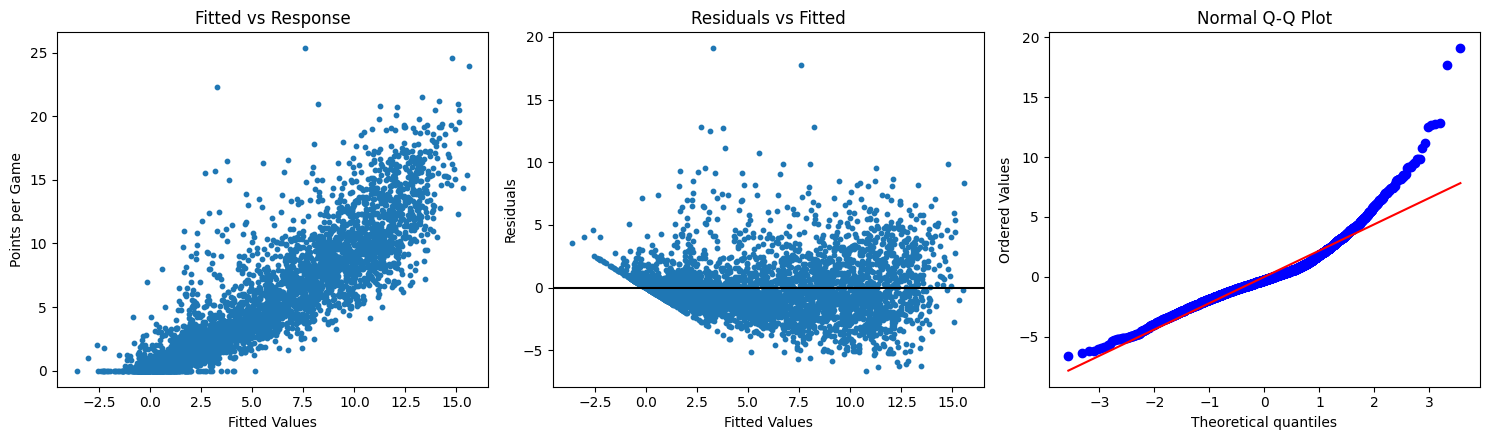

In [5]:
e_hat = model.resid
y_hat = model.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].scatter(y_hat, data_clean["pts"], s=10)
axes[0].set_xlabel("Fitted Values")
axes[0].set_ylabel("Points per Game")
axes[0].set_title("Fitted vs Response")

axes[1].scatter(y_hat, e_hat, s=10)
axes[1].axhline(0, color="black")
axes[1].set_xlabel("Fitted Values")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Residuals vs Fitted")

stats.probplot(e_hat, dist="norm", plot=axes[2])
axes[2].set_title("Normal Q-Q Plot")

plt.tight_layout()
plt.show()


# 5. HISTOGRAMS & DESCRIPTIVE GRAPHS

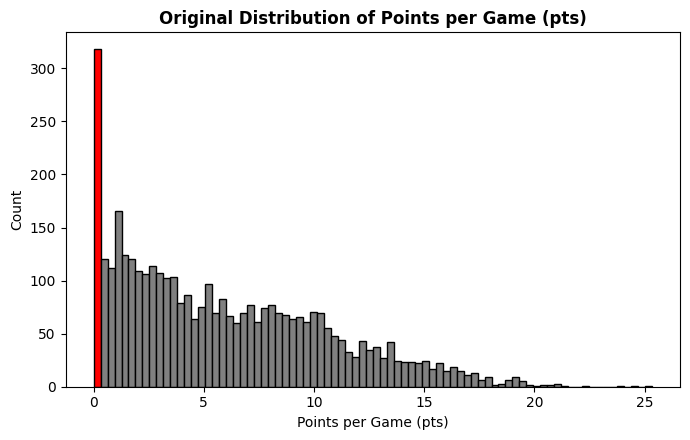

In [6]:
# Histogram of pts, with the first bin highlighted in red
counts, bins = np.histogram(data_clean["pts"], bins=80)
bar_colors = ["red"] + ["grey"] * (len(counts) - 1)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(bins[:-1], counts, width=np.diff(bins), align="edge",
       color=bar_colors, edgecolor="black")
ax.set_title("Original Distribution of Points per Game (pts)", fontweight="bold")
ax.set_xlabel("Points per Game (pts)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


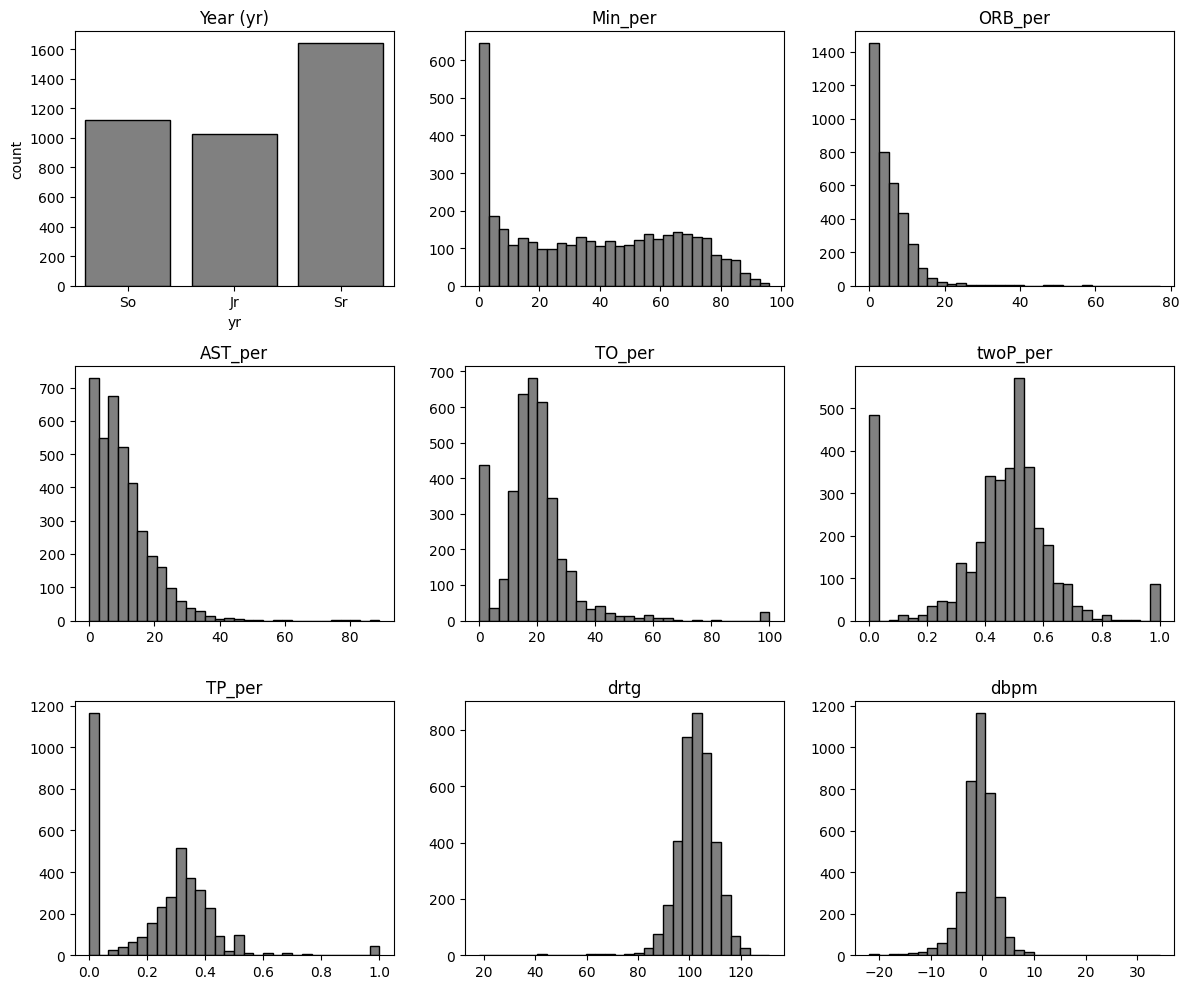

In [7]:
# Grid of descriptive plots, analogous to the patchwork layout (p1..p9)
fig, axes = plt.subplots(3, 3, figsize=(12, 10))

sns.countplot(x="yr", data=data_clean, color="grey", edgecolor="black", ax=axes[0, 0])
axes[0, 0].set_title("Year (yr)")

hist_vars = ["Min_per", "ORB_per", "AST_per", "TO_per", "twoP_per", "TP_per", "drtg", "dbpm"]
positions = [(0, 1), (0, 2), (1, 0), (1, 1), (1, 2), (2, 0), (2, 1), (2, 2)]

for var, (r, c) in zip(hist_vars, positions):
    axes[r, c].hist(data_clean[var], bins=30, color="grey", edgecolor="black")
    axes[r, c].set_title(var)

plt.tight_layout()
plt.show()


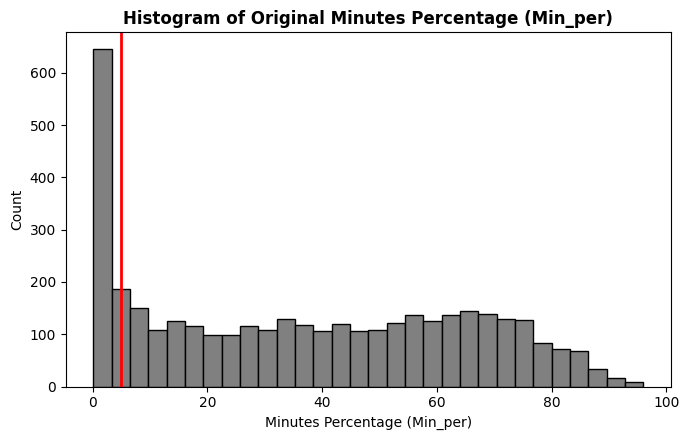

In [8]:
# Histogram of Min_per with a vertical reference line at 5
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(data_clean["Min_per"], bins=30, color="grey", edgecolor="black")
ax.axvline(5, color="red", linewidth=2)
ax.set_title("Histogram of Original Minutes Percentage (Min_per)", fontweight="bold")
ax.set_xlabel("Minutes Percentage (Min_per)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


# 6. INTERACTION PLOT

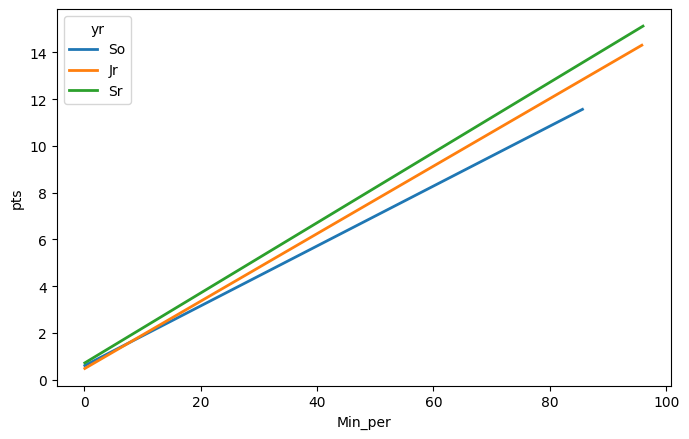

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for year in YEAR_LEVELS:
    sub = data_clean[data_clean["yr"] == year]
    sns.regplot(x="Min_per", y="pts", data=sub, scatter=False,
                ci=None, label=year, line_kws={"linewidth": 2}, ax=ax)
ax.set_xlabel("Min_per")
ax.set_ylabel("pts")
ax.legend(title="yr")
plt.tight_layout()
plt.show()


# 7. CORRELATION MATRIX FOR ORIGINAL MODEL

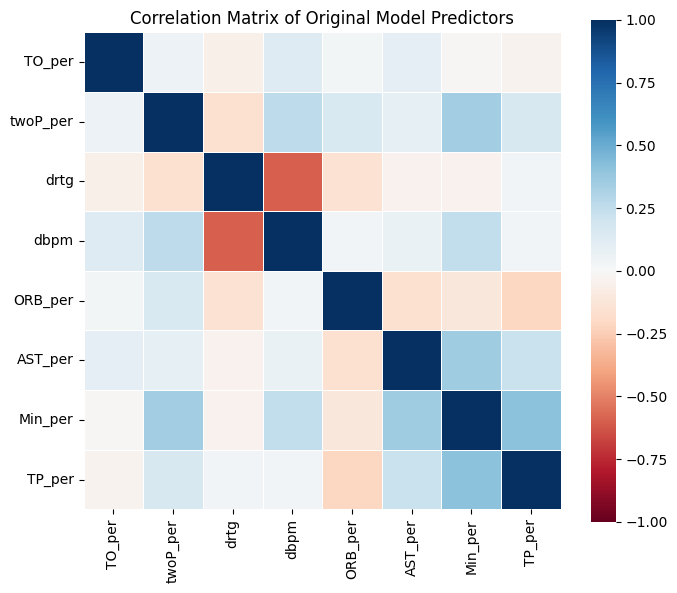

In [10]:
numeric_predictors = data_clean[["Min_per", "ORB_per", "AST_per", "TO_per",
                                  "twoP_per", "drtg", "TP_per", "dbpm"]]

cor_matrix = numeric_predictors.corr()

# hierarchical clustering ordering, analogous to corrplot's order = "hclust"
dist = 1 - cor_matrix.abs()
condensed = squareform(dist.values, checks=False)
link = linkage(condensed, method="average")
order = leaves_list(link)
ordered_cols = cor_matrix.columns[order]
cor_matrix_ordered = cor_matrix.loc[ordered_cols, ordered_cols]

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cor_matrix_ordered, cmap="RdBu", vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar=True, ax=ax)
ax.set_title("Correlation Matrix of Original Model Predictors")
plt.tight_layout()
plt.show()


# 8. CLEAN DATA FOR BOX-COX MODEL

In [11]:
cols_2 = ["pts", "yr", "Min_per", "treb", "AST_per", "TO_per", "TS_per", "dbpm"]

data_clean2 = data[cols_2].copy()
data_clean2 = data_clean2.dropna(subset=["yr", "pts"])
data_clean2 = data_clean2.dropna()

data_clean2 = data_clean2[
    between(data_clean2["treb"], 0, 100) &
    between(data_clean2["AST_per"], 0, 100) &
    between(data_clean2["TO_per"], 0, 100) &
    between(data_clean2["TS_per"], 0, 100)
]

data_clean2 = data_clean2[
    (data_clean2["pts"] > 0) &
    (data_clean2["Min_per"] > 5) &
    (data_clean2["dbpm"] < 100)
]

data_clean2["yr"] = pd.Categorical(data_clean2["yr"], categories=YEAR_LEVELS, ordered=False)
data_clean2 = data_clean2.reset_index(drop=True)

data_clean2.shape


(3022, 8)

# 9. FIT NON-TRANSFORMED MODEL 2

In [12]:
formula_final = (
    "pts ~ C(yr, levels=YEAR_LEVELS) + Min_per + treb + AST_per + TO_per + "
    "TS_per + dbpm + C(yr, levels=YEAR_LEVELS):Min_per"
)

model_final = smf.ols(formula_final, data=data_clean2).fit()
print(model_final.summary())


                            OLS Regression Results                            
Dep. Variable:                    pts   R-squared:                       0.781
Model:                            OLS   Adj. R-squared:                  0.780
Method:                 Least Squares   F-statistic:                     1073.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:04:12   Log-Likelihood:                -6491.0
No. Observations:                3022   AIC:                         1.300e+04
Df Residuals:                    3011   BIC:                         1.307e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

# 10. BOX-COX TRANSFORMATION

Estimated lambda: 0.4351


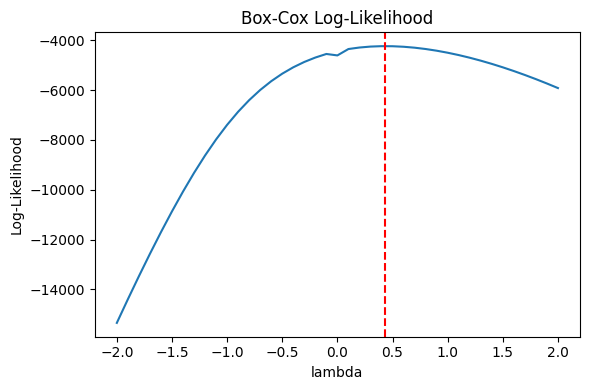

In [13]:
model_initial = smf.ols(formula_final, data=data_clean2).fit()

# scipy's boxcox works directly on the (positive) response and finds the
# optimal lambda by profile likelihood - equivalent to MASS::boxcox()
bc_pts_vals, lam = boxcox(data_clean2["pts"])
lambda_ = lam

data_clean2["bc_pts"] = (data_clean2["pts"] ** lambda_ - 1) / lambda_

print(f"Estimated lambda: {lambda_:.4f}")

# Optional: visualize the log-likelihood curve like MASS::boxcox(lambda=seq(-2,2,0.1))
lambdas = np.arange(-2, 2.01, 0.1)
llf = [stats.boxcox_llf(l, data_clean2["pts"]) for l in lambdas]
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(lambdas, llf)
ax.axvline(lambda_, color="red", linestyle="--")
ax.set_xlabel("lambda")
ax.set_ylabel("Log-Likelihood")
ax.set_title("Box-Cox Log-Likelihood")
plt.tight_layout()
plt.show()


# 11. FIT BOX-COX MODEL

In [14]:
formula_bc = (
    "bc_pts ~ C(yr, levels=YEAR_LEVELS) + Min_per + treb + AST_per + TO_per + "
    "TS_per + dbpm + C(yr, levels=YEAR_LEVELS):Min_per"
)

model_bc = smf.ols(formula_bc, data=data_clean2).fit()
print(model_bc.summary())


                            OLS Regression Results                            
Dep. Variable:                 bc_pts   R-squared:                       0.832
Model:                            OLS   Adj. R-squared:                  0.832
Method:                 Least Squares   F-statistic:                     1494.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:04:12   Log-Likelihood:                -2872.0
No. Observations:                3022   AIC:                             5766.
Df Residuals:                    3011   BIC:                             5832.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

# 12. BOX-COX DIAGNOSTICS

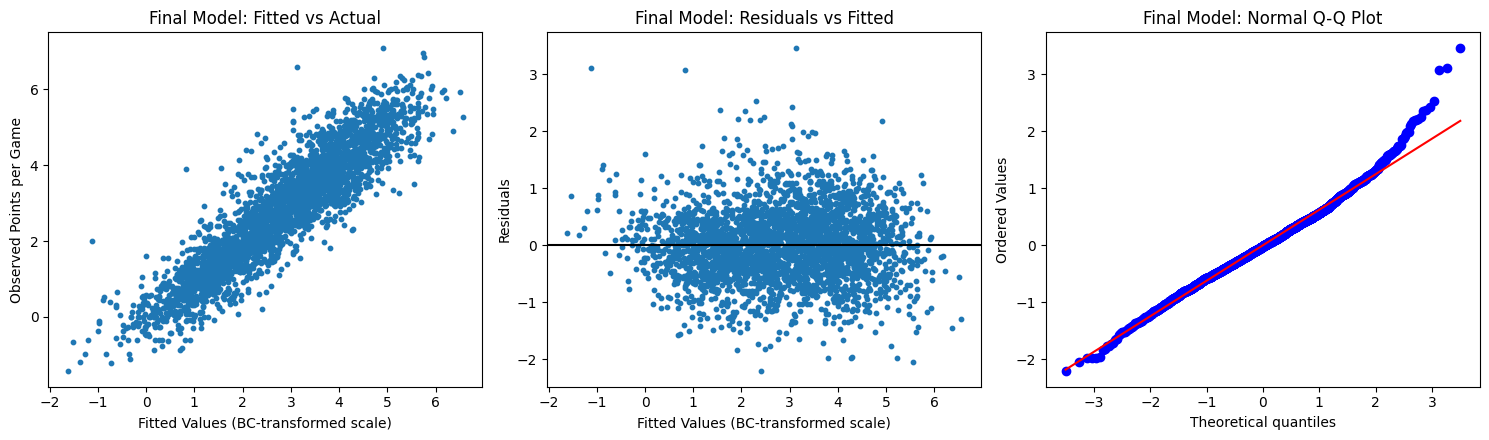

In [15]:
e_hat_final = model_bc.resid
y_hat_final = model_bc.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].scatter(y_hat_final, data_clean2["bc_pts"], s=10)
axes[0].set_xlabel("Fitted Values (BC-transformed scale)")
axes[0].set_ylabel("Observed Points per Game")
axes[0].set_title("Final Model: Fitted vs Actual")

axes[1].scatter(y_hat_final, e_hat_final, s=10)
axes[1].axhline(0, color="black")
axes[1].set_xlabel("Fitted Values (BC-transformed scale)")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Final Model: Residuals vs Fitted")

stats.probplot(e_hat_final, dist="norm", plot=axes[2])
axes[2].set_title("Final Model: Normal Q-Q Plot")

plt.tight_layout()
plt.show()


# 13. PARTIAL F TESTS

In [16]:
model_full = model_bc

def refit_dropping(formula_terms, drop_term, data=data_clean2, response="bc_pts"):
    terms = [t for t in formula_terms if t != drop_term]
    f = f"{response} ~ " + " + ".join(terms)
    return smf.ols(f, data=data).fit()

full_terms = [
    "C(yr, levels=YEAR_LEVELS)", "Min_per", "treb", "AST_per", "TO_per",
    "TS_per", "dbpm", "C(yr, levels=YEAR_LEVELS):Min_per",
]

model_no_AST = refit_dropping(full_terms, "AST_per")
print(anova_lm(model_no_AST, model_full))

model_no_TO = refit_dropping(full_terms, "TO_per")
print(anova_lm(model_no_TO, model_full))

model_no_TS = refit_dropping(full_terms, "TS_per")
print(anova_lm(model_no_TS, model_full))

model_no_interaction = refit_dropping(full_terms, "C(yr, levels=YEAR_LEVELS):Min_per")
print(anova_lm(model_no_interaction, model_full))

model_no_skills = smf.ols(
    "bc_pts ~ C(yr, levels=YEAR_LEVELS) + Min_per + dbpm + "
    "C(yr, levels=YEAR_LEVELS):Min_per",
    data=data_clean2
).fit()
print(anova_lm(model_no_skills, model_full))

model_min_only = smf.ols(
    "bc_pts ~ Min_per + C(yr, levels=YEAR_LEVELS):Min_per",
    data=data_clean2
).fit()
print(anova_lm(model_min_only, model_full))


   df_resid          ssr  df_diff     ss_diff           F         Pr(>F)
0    3012.0  1380.979748      0.0         NaN         NaN            NaN
1    3011.0  1183.851891      1.0  197.127858  501.373511  7.613874e-103
   df_resid          ssr  df_diff     ss_diff           F        Pr(>F)
0    3012.0  1324.815498      0.0         NaN         NaN           NaN
1    3011.0  1183.851891      1.0  140.963607  358.525779  1.236259e-75
   df_resid          ssr  df_diff     ss_diff           F         Pr(>F)
0    3012.0  1388.301558      0.0         NaN         NaN            NaN
1    3011.0  1183.851891      1.0  204.449667  519.995746  2.615068e-106
   df_resid          ssr  df_diff   ss_diff         F    Pr(>F)
0    3013.0  1186.970787      0.0       NaN       NaN       NaN
1    3011.0  1183.851891      2.0  3.118896  3.966289  0.019043
   df_resid          ssr  df_diff     ss_diff           F  Pr(>F)
0    3015.0  2020.011769      0.0         NaN         NaN     NaN
1    3011.0  1183.8518

# 14. INFLUENCE DIAGNOSTICS

In [17]:
infl = OLSInfluence(model_bc)

lev = infl.hat_matrix_diag
rstd = infl.resid_studentized_internal
cd = infl.cooks_distance[0]
dff = infl.dffits[0]
dfb = infl.dfbetas  # array, shape (n, p+1)

p = len(model_bc.params) - 1  # number of predictors (excluding intercept)
n = len(data_clean2)

cut_lev = 2 * (p + 1) / n
cut_r = 4
cut_cd = stats.f.ppf(0.5, p + 1, n - p - 1)
cut_dff = 2 * np.sqrt((p + 1) / n)
cut_dfb = 2 / np.sqrt(n)

print("High leverage:", np.where(lev > cut_lev)[0])
print("Outliers (|rstandard| > 4):", np.where(np.abs(rstd) > cut_r)[0])
print("Influential (Cook's D):", np.where(cd > cut_cd)[0])
print("Influential (DFFITS):", np.where(np.abs(dff) > cut_dff)[0])

dfb_flags = {model_bc.params.index[j]: np.where(np.abs(dfb[:, j]) > cut_dfb)[0]
             for j in range(dfb.shape[1])}
dfb_flags


High leverage: [  57   96  103  232  314  348  384  387  395  432  577  581  593  608
  611  624  626  677  697  723  731  735  762  779  785  802  871  881
  886  899  942  974  998 1022 1034 1047 1069 1095 1131 1150 1164 1202
 1227 1229 1230 1237 1275 1282 1317 1342 1353 1361 1369 1405 1406 1410
 1458 1459 1462 1479 1482 1508 1516 1538 1550 1553 1568 1577 1579 1615
 1620 1648 1711 1722 1738 1744 1787 1808 1819 1821 1824 1861 1890 1895
 1947 1981 1991 1999 2007 2014 2020 2023 2029 2042 2044 2068 2072 2088
 2096 2100 2137 2174 2175 2183 2184 2192 2203 2207 2222 2267 2271 2272
 2276 2279 2288 2289 2297 2301 2304 2308 2316 2326 2327 2340 2345 2349
 2355 2365 2375 2406 2437 2450 2476 2505 2506 2513 2525 2532 2533 2536
 2544 2545 2549 2564 2566 2575 2580 2599 2604 2608 2609 2613 2626 2637
 2642 2643 2650 2658 2663 2664 2677 2720 2723 2732 2738 2739 2745 2746
 2760 2762 2783 2785 2794 2814 2815 2826 2852 2859 2862 2863 2876 2895
 2903 2923 2927 2946 2951 2953 2958 2960 2970 2977 2990 3002 3

{'Intercept': array([  46,   49,   57,   64,  103,  106,  145,  159,  160,  177,  297,
         314,  332,  376,  384,  408,  432,  454,  507,  517,  519,  550,
         578,  581,  593,  608,  635,  637,  671,  697,  719,  726,  735,
         753,  762,  780,  798,  802,  871,  882,  890,  902,  974,  984,
         999, 1022, 1035, 1037, 1047, 1069, 1089, 1095, 1168, 1182, 1211,
        1227, 1230, 1237, 1247, 1324, 1349, 1363, 1369, 1377, 1422, 1430,
        1432, 1458, 1459, 1508, 1538, 1593, 1597, 1620, 1629, 1658, 1665,
        1699, 1731, 1735, 1738, 1741, 1821, 1834, 1885, 1895, 1911, 1914,
        1920, 2007, 2016, 2020, 2029, 2042, 2075, 2100, 2115, 2140, 2149,
        2159, 2160, 2197, 2206, 2207, 2255, 2267, 2276, 2280, 2295, 2301,
        2308, 2340, 2347, 2370, 2375, 2392, 2395, 2406, 2442, 2444, 2465,
        2473, 2491, 2533, 2536, 2544, 2566, 2575, 2588, 2608, 2630, 2663,
        2677, 2678, 2688, 2715, 2723, 2732, 2733, 2736, 2742, 2762, 2779,
        2791, 2804, 2828,

# 15. MODEL COMPARISON TABLE

In [18]:
model1 = model
model2 = model_bc

comparison = pd.DataFrame({
    "Metric": ["Adjusted R2", "AIC", "BIC"],
    "Model1": [model1.rsquared_adj, model1.aic, model1.bic],
    "Model2": [model2.rsquared_adj, model2.aic, model2.bic],
})

comparison


,Metric,Model1,Model2
0,Adjusted R2,0.766430,0.831719
1,AIC,16988.012718,5766.011013
2,BIC,17069.103387,5832.161429


# 16. CORRELATION HEATMAP FOR BOX-COX MODEL

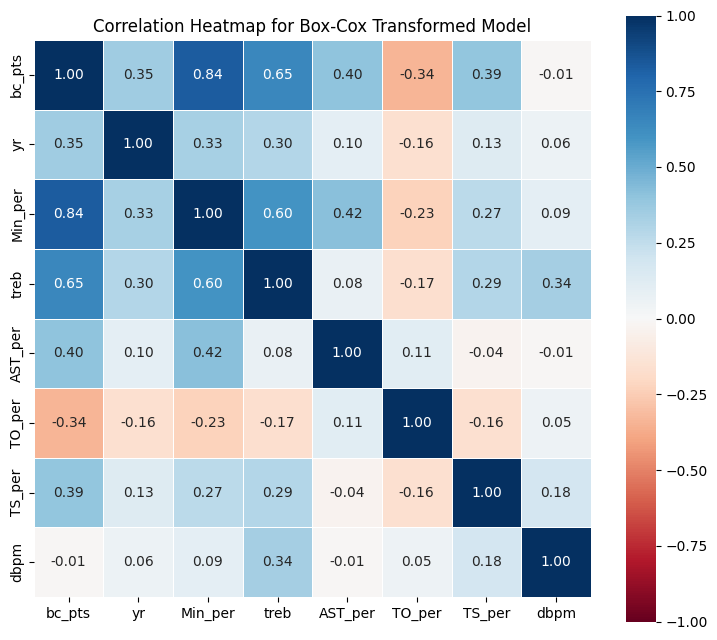

In [19]:
data_bc = data_clean2.copy()
data_bc["bc_pts"] = (data_bc["pts"] ** lambda_ - 1) / lambda_

data_corr = data_bc[["bc_pts", "yr", "Min_per", "treb", "AST_per", "TO_per", "TS_per", "dbpm"]].copy()
data_corr["yr"] = data_corr["yr"].cat.codes + 1  # numeric encoding, like as.numeric(factor(yr))

corr_mat = data_corr.corr()

fig, ax = plt.subplots(figsize=(7.5, 6.5))
sns.heatmap(corr_mat, cmap="RdBu", vmin=-1, vmax=1, annot=True, fmt=".2f",
            square=True, linewidths=0.5, cbar=True, ax=ax)
ax.set_title("Correlation Heatmap for Box-Cox Transformed Model")
plt.tight_layout()
plt.show()


**SUMMARY**

In [20]:
print(model_bc.summary())


                            OLS Regression Results                            
Dep. Variable:                 bc_pts   R-squared:                       0.832
Model:                            OLS   Adj. R-squared:                  0.832
Method:                 Least Squares   F-statistic:                     1494.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:04:20   Log-Likelihood:                -2872.0
No. Observations:                3022   AIC:                             5766.
Df Residuals:                    3011   BIC:                             5832.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

# 16. Multicollinearity check (VIF)

In [21]:
# statsmodels' VIF is computed on the design matrix (type="predictor" analog):
# build the design matrix used by model_bc and compute VIF per column
X = sm.add_constant(pd.get_dummies(
    data_clean2[["yr", "Min_per", "treb", "AST_per", "TO_per", "TS_per", "dbpm"]],
    columns=["yr"], drop_first=True
).astype(float))

vif_table = pd.DataFrame({
    "variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
vif_table


,variable,VIF
0,const,1.000000
1,Min_per,2.247923
2,treb,1.918680
3,AST_per,1.371152
4,TO_per,1.143878
5,TS_per,1.154300
6,dbpm,1.185994
7,yr_Jr,1.606619
8,yr_Sr,1.766309


# 17. Paired plots for multicollinearity check

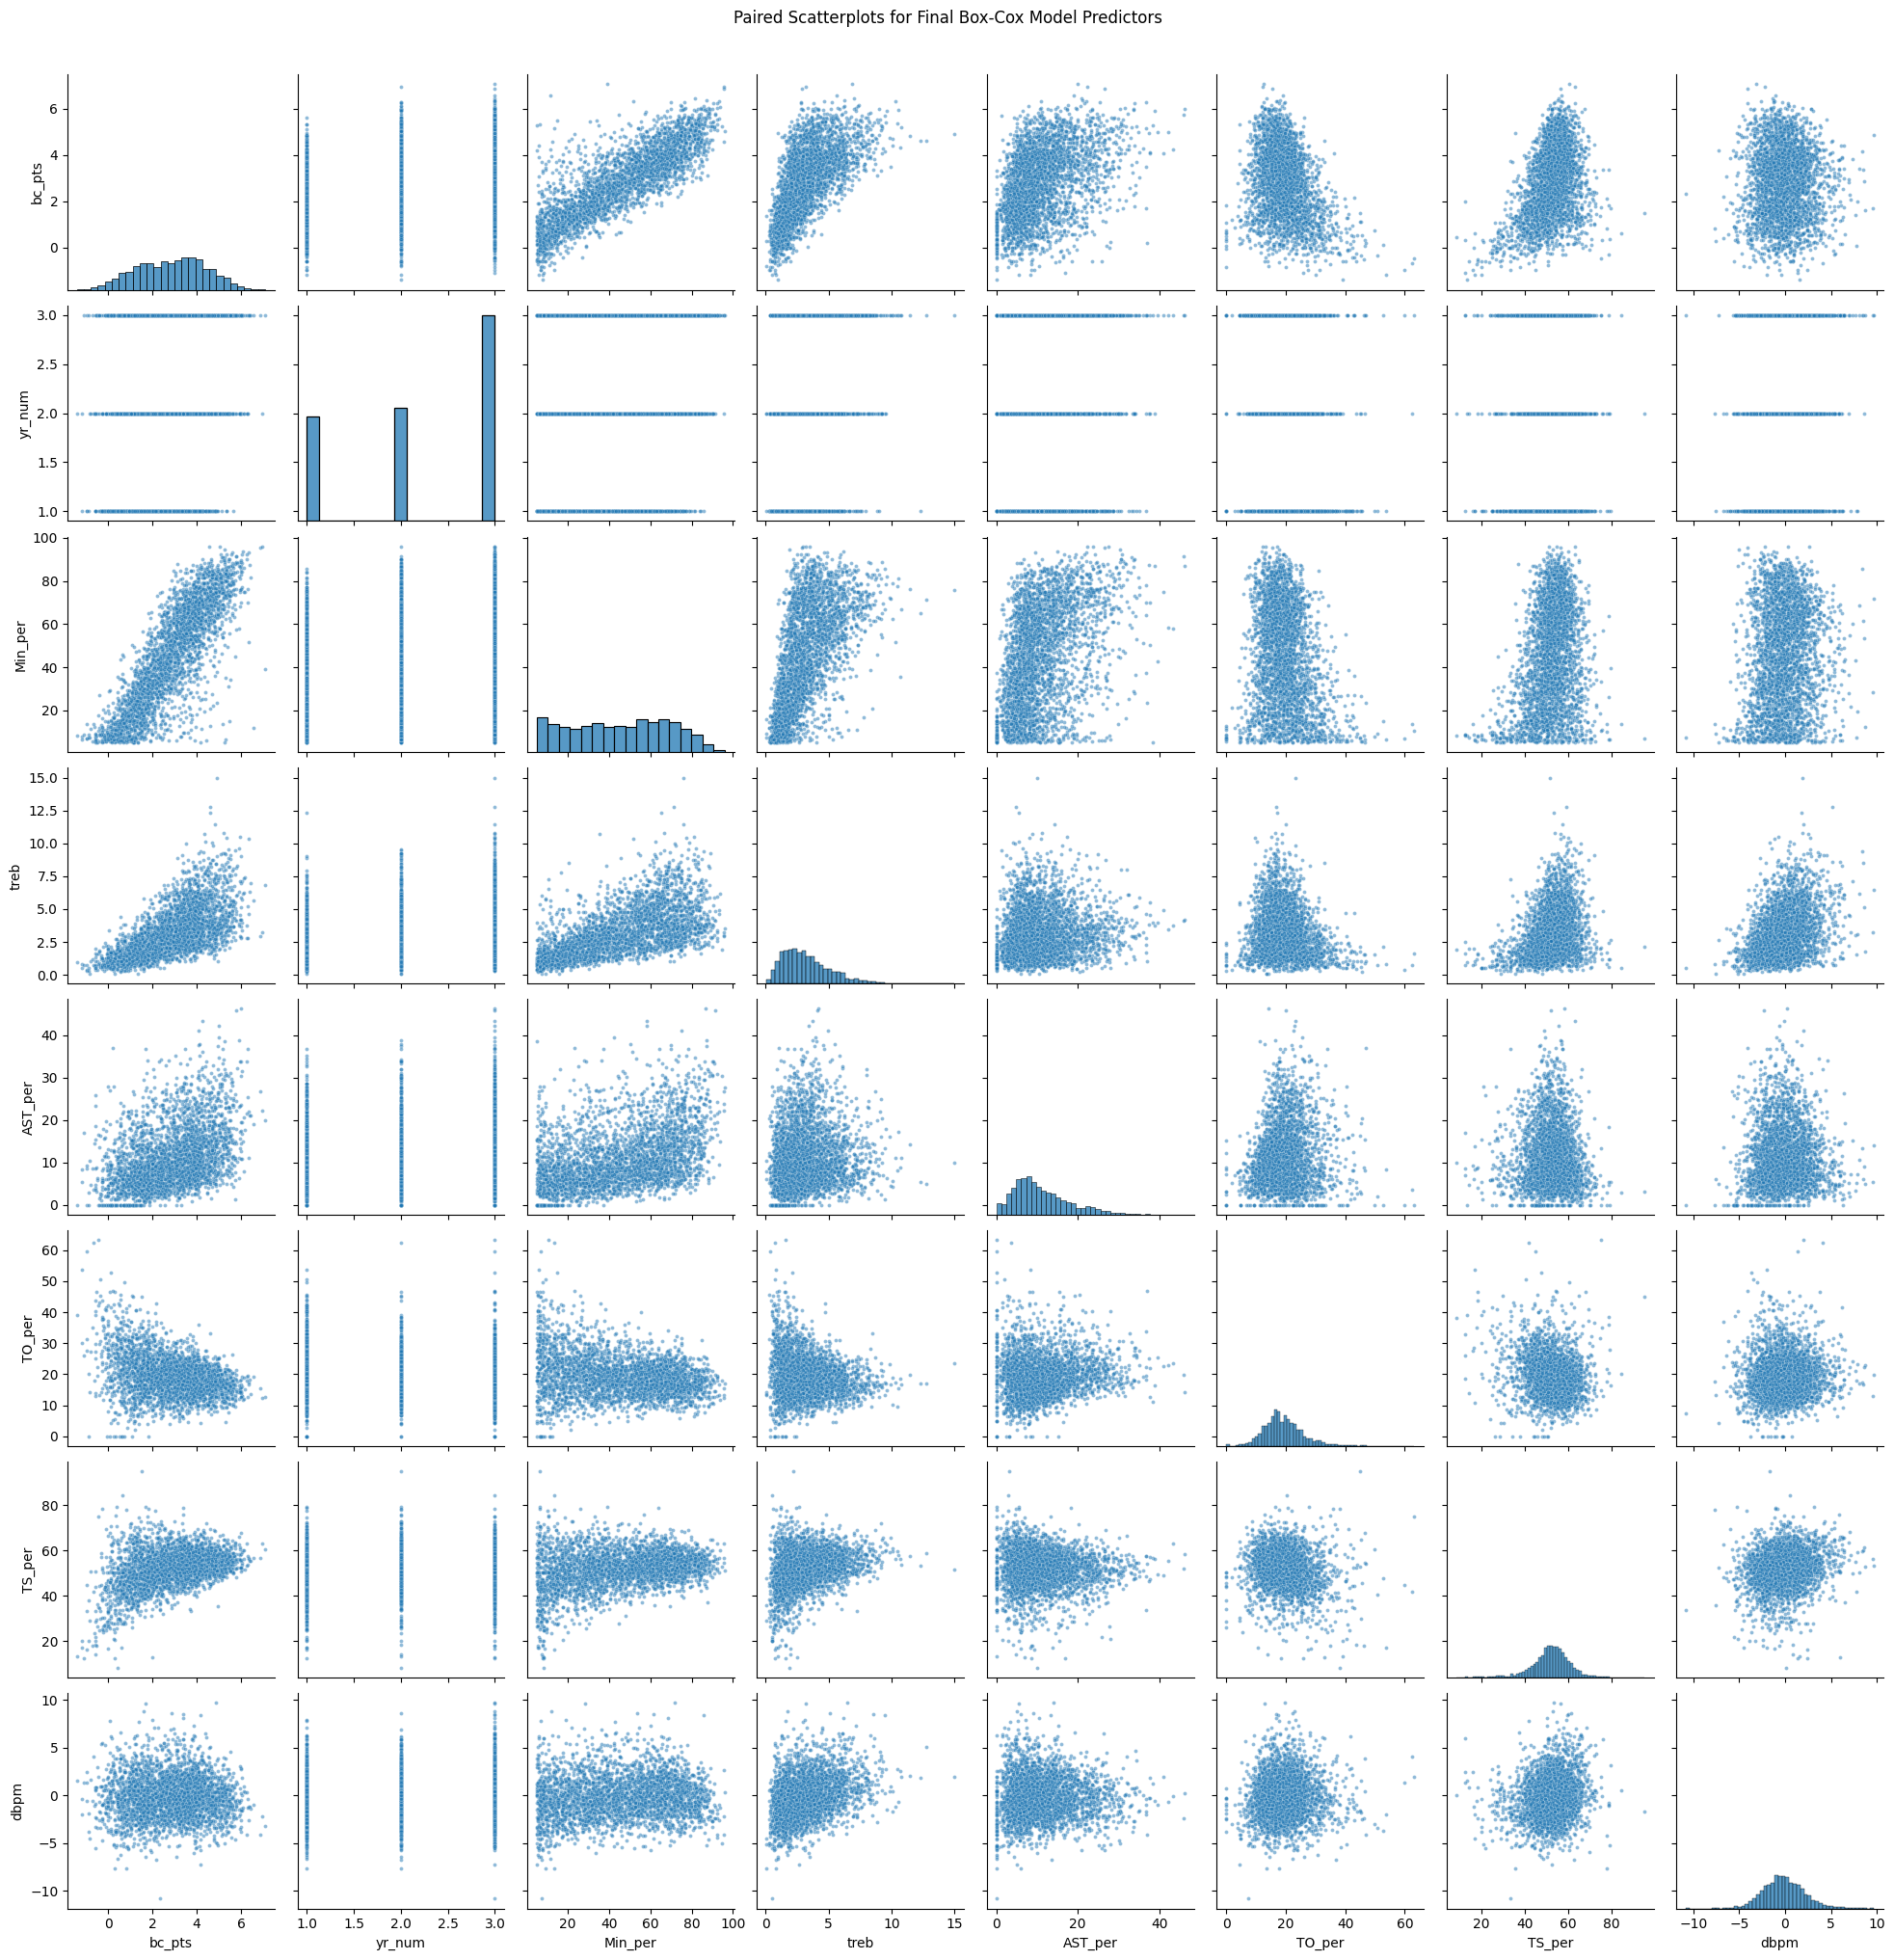

In [22]:
pairs_data = data_clean2.copy()
pairs_data["bc_pts"] = (pairs_data["pts"] ** lambda_ - 1) / lambda_
pairs_data["yr_num"] = pairs_data["yr"].cat.codes + 1

pairs_data = pairs_data[["bc_pts", "yr_num", "Min_per", "treb", "AST_per", "TO_per", "TS_per", "dbpm"]]

g = sns.pairplot(pairs_data, plot_kws={"s": 8, "alpha": 0.5})
g.fig.suptitle("Paired Scatterplots for Final Box-Cox Model Predictors", y=1.02)
plt.show()


# 18. Graph for interaction

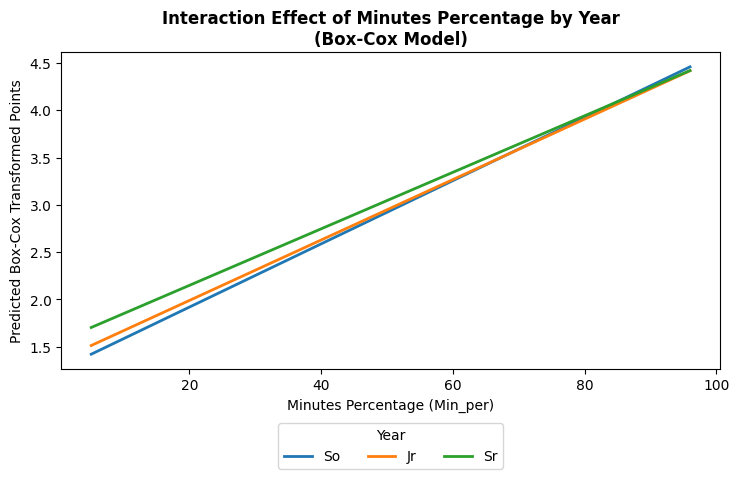

In [23]:
min_per_seq = np.linspace(data_clean2["Min_per"].min(), data_clean2["Min_per"].max(), 200)

newdata = pd.DataFrame([
    {
        "Min_per": m,
        "yr": y,
        "treb": data_clean2["treb"].mean(),
        "AST_per": data_clean2["AST_per"].mean(),
        "TO_per": data_clean2["TO_per"].mean(),
        "TS_per": data_clean2["TS_per"].mean(),
        "dbpm": data_clean2["dbpm"].mean(),
    }
    for m in min_per_seq for y in YEAR_LEVELS
])
newdata["yr"] = pd.Categorical(newdata["yr"], categories=YEAR_LEVELS)

newdata["pred"] = model_bc.predict(newdata)

fig, ax = plt.subplots(figsize=(7.5, 5))
for y in YEAR_LEVELS:
    sub = newdata[newdata["yr"] == y]
    ax.plot(sub["Min_per"], sub["pred"], linewidth=2, label=y)

ax.set_title("Interaction Effect of Minutes Percentage by Year\n(Box-Cox Model)", fontweight="bold")
ax.set_xlabel("Minutes Percentage (Min_per)")
ax.set_ylabel("Predicted Box-Cox Transformed Points")
ax.legend(title="Year", loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3)
plt.tight_layout()
plt.show()


# 19. Forward Backward Transformation

`statsmodels` has no built-in `stepAIC`, so a small helper implementing
forward / backward / bidirectional stepwise selection by AIC is defined below.
It operates on model *terms* (so the categorical `yr` and the `yr:Min_per`
interaction are each treated as a single term, like in R's `step()`).


In [24]:
ALL_TERMS = [
    "C(yr, levels=YEAR_LEVELS)", "Min_per", "treb", "AST_per", "TO_per",
    "TS_per", "dbpm", "C(yr, levels=YEAR_LEVELS):Min_per",
]

def fit_terms(terms, data=data_clean2, response="bc_pts"):
    if not terms:
        f = f"{response} ~ 1"
    else:
        f = f"{response} ~ " + " + ".join(terms)
    return smf.ols(f, data=data).fit()

def stepwise_selection(all_terms, direction="both", data=data_clean2,
                        response="bc_pts", verbose=True):
    if direction == "forward":
        current = []
    else:
        current = list(all_terms)

    current_aic = fit_terms(current, data, response).aic
    improved = True

    while improved:
        improved = False
        candidates = []

        if direction in ("backward", "both") and current:
            for t in current:
                trial = [x for x in current if x != t]
                aic = fit_terms(trial, data, response).aic
                candidates.append((aic, "remove", t, trial))

        if direction in ("forward", "both"):
            for t in all_terms:
                if t not in current:
                    trial = current + [t]
                    aic = fit_terms(trial, data, response).aic
                    candidates.append((aic, "add", t, trial))

        if candidates:
            candidates.sort(key=lambda x: x[0])
            best_aic, action, term, trial = candidates[0]
            if best_aic < current_aic:
                if verbose:
                    print(f"{action}: {term}  (AIC {current_aic:.2f} -> {best_aic:.2f})")
                current, current_aic = trial, best_aic
                improved = True

    return fit_terms(current, data, response), current

model_backward, terms_backward = stepwise_selection(ALL_TERMS, direction="backward")
print(model_backward.summary())

model_forward, terms_forward = stepwise_selection(ALL_TERMS, direction="forward")
print(model_forward.summary())

model_stepwise, terms_stepwise = stepwise_selection(ALL_TERMS, direction="both")
print(model_stepwise.summary())

aic_table = pd.DataFrame({
    "model": ["backward", "forward", "stepwise"],
    "AIC": [model_backward.aic, model_forward.aic, model_stepwise.aic],
    "BIC": [model_backward.bic, model_forward.bic, model_stepwise.bic],
})
aic_table


                            OLS Regression Results                            
Dep. Variable:                 bc_pts   R-squared:                       0.832
Model:                            OLS   Adj. R-squared:                  0.832
Method:                 Least Squares   F-statistic:                     1494.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:04:25   Log-Likelihood:                -2872.0
No. Observations:                3022   AIC:                             5766.
Df Residuals:                    3011   BIC:                             5832.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

,model,AIC,BIC
0,backward,5766.011013,5832.161429
1,forward,5766.011013,5832.161429
2,stepwise,5766.011013,5832.161429


# 20. Test if Min_per is relevant

In [25]:
model_no_interaction = refit_dropping(full_terms, "C(yr, levels=YEAR_LEVELS):Min_per")
print(anova_lm(model_no_interaction, model_bc))

no_interaction_terms = [t for t in full_terms if t != "C(yr, levels=YEAR_LEVELS):Min_per"]
model_no_min = fit_terms([t for t in no_interaction_terms if t != "Min_per"])
print(anova_lm(model_no_min, model_no_interaction))


   df_resid          ssr  df_diff   ss_diff         F    Pr(>F)
0    3013.0  1186.970787      0.0       NaN       NaN       NaN
1    3011.0  1183.851891      2.0  3.118896  3.966289  0.019043
   df_resid          ssr  df_diff    ss_diff            F         Pr(>F)
0    3014.0  1921.487878      0.0        NaN          NaN            NaN
1    3013.0  1186.970787      1.0  734.51709  1864.494069  1.639751e-317


# Split Model

In [26]:
SEED = 67

data_val = data_clean2.copy()

train, test = train_test_split(data_val, test_size=0.2, random_state=SEED)
train = train.reset_index(drop=True)
test = test.reset_index(drop=True)

len(train), len(test)


(2417, 605)

# Build model in each dataset

In [27]:
model_train = smf.ols(formula_bc, data=train).fit()
print(model_train.summary())

model_test = smf.ols(formula_bc, data=test).fit()
print(model_test.summary())


                            OLS Regression Results                            
Dep. Variable:                 bc_pts   R-squared:                       0.834
Model:                            OLS   Adj. R-squared:                  0.833
Method:                 Least Squares   F-statistic:                     1205.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:04:26   Log-Likelihood:                -2268.2
No. Observations:                2417   AIC:                             4558.
Df Residuals:                    2406   BIC:                             4622.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

# Compare the two models using VIF

In [28]:
def vif_for(df):
    X = sm.add_constant(pd.get_dummies(
        df[["yr", "Min_per", "treb", "AST_per", "TO_per", "TS_per", "dbpm"]],
        columns=["yr"], drop_first=True
    ).astype(float))
    return pd.DataFrame({
        "variable": X.columns,
        "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    })

print(vif_for(train))
print(vif_for(test))


  variable       VIF
0    const  1.000000
1  Min_per  2.219664
2     treb  1.937571
3  AST_per  1.355542
4   TO_per  1.140959
5   TS_per  1.144268
6     dbpm  1.181048
7    yr_Jr  1.582620
8    yr_Sr  1.746639
  variable       VIF
0    const  1.000000
1  Min_per  2.380168
2     treb  1.853891
3  AST_per  1.458576
4   TO_per  1.168673
5   TS_per  1.212066
6     dbpm  1.221667
7    yr_Jr  1.714956
8    yr_Sr  1.869769


# Check Assumptions

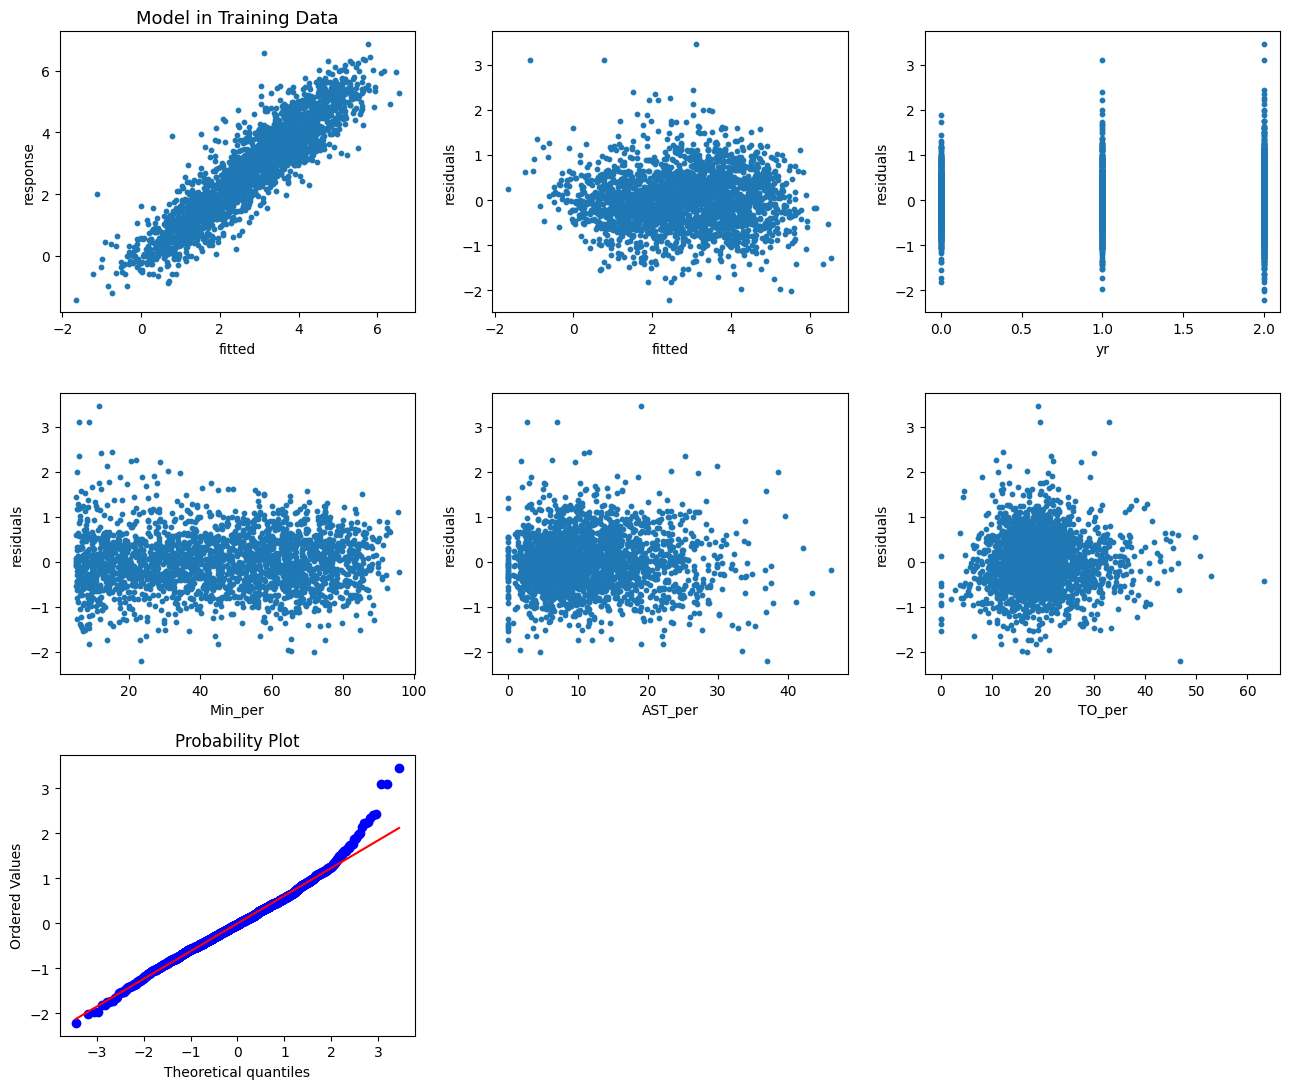

In [29]:
# Training diagnostics
fig, axes = plt.subplots(3, 3, figsize=(13, 11))
axes = axes.flatten()

axes[0].scatter(model_train.fittedvalues, train["bc_pts"], s=10)
axes[0].set_xlabel("fitted"); axes[0].set_ylabel("response")
axes[0].set_title("Model in Training Data", fontsize=13)

axes[1].scatter(model_train.fittedvalues, model_train.resid, s=10)
axes[1].set_xlabel("fitted"); axes[1].set_ylabel("residuals")

resid_vars = ["yr", "Min_per", "AST_per", "TO_per"]  # matches R's train[[c(2,3,5,6)]]
for ax, var in zip(axes[2:6], resid_vars):
    if var == "yr":
        ax.scatter(train[var].cat.codes, model_train.resid, s=10)
    else:
        ax.scatter(train[var], model_train.resid, s=10)
    ax.set_xlabel(var); ax.set_ylabel("residuals")

stats.probplot(model_train.resid, dist="norm", plot=axes[6])

for ax in axes[7:]:
    ax.axis("off")

plt.tight_layout()
plt.show()


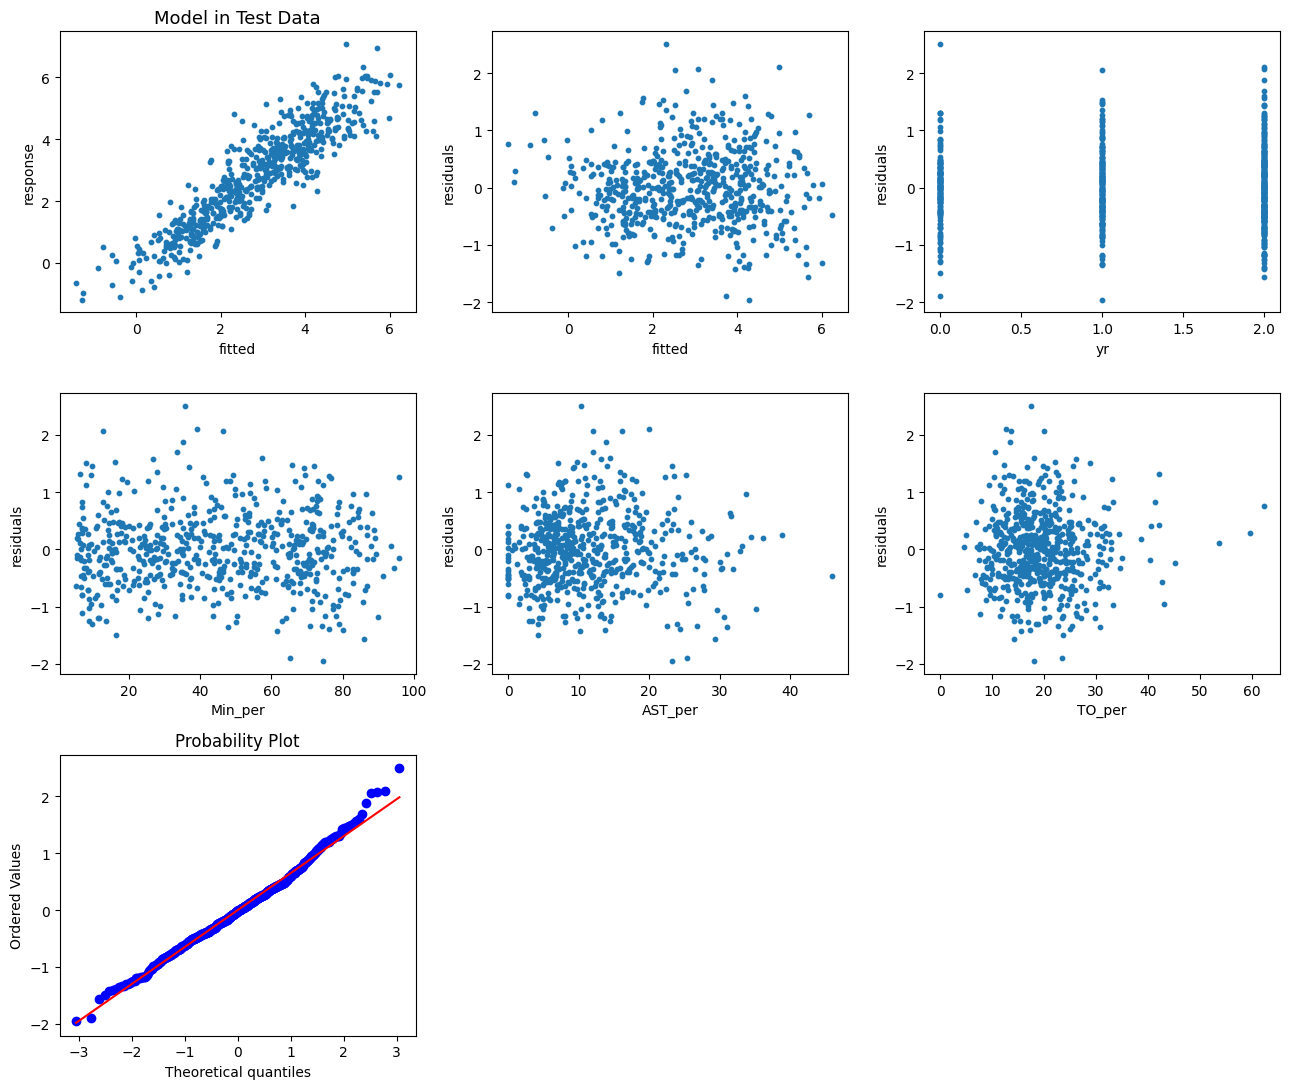

In [30]:
# Test diagnostics
fig, axes = plt.subplots(3, 3, figsize=(13, 11))
axes = axes.flatten()

axes[0].scatter(model_test.fittedvalues, test["bc_pts"], s=10)
axes[0].set_xlabel("fitted"); axes[0].set_ylabel("response")
axes[0].set_title("Model in Test Data", fontsize=13)

axes[1].scatter(model_test.fittedvalues, model_test.resid, s=10)
axes[1].set_xlabel("fitted"); axes[1].set_ylabel("residuals")

for ax, var in zip(axes[2:6], resid_vars):
    if var == "yr":
        ax.scatter(test[var].cat.codes, model_test.resid, s=10)
    else:
        ax.scatter(test[var], model_test.resid, s=10)
    ax.set_xlabel(var); ax.set_ylabel("residuals")

stats.probplot(model_test.resid, dist="norm", plot=axes[6])

for ax in axes[7:]:
    ax.axis("off")

plt.tight_layout()
plt.show()


# Check Problematic Points

In [31]:
def problematic_points(fitted_model, df, label):
    print(label)
    n = len(df)
    p = len(fitted_model.params) - 1

    infl = OLSInfluence(fitted_model)
    lev = infl.hat_matrix_diag
    rstd = infl.resid_studentized_internal
    cd = infl.cooks_distance[0]
    dff = infl.dffits[0]
    dfb = infl.dfbetas

    h_cut = 2 * (p + 1) / n
    print("Leverage Points")
    print(np.where(lev > h_cut)[0])

    print("Outliers")
    print(np.where((rstd > 2) | (rstd < -2))[0])

    D_cut = stats.f.ppf(0.5, p + 1, n - p - 1)
    print("Influence (Cooks)")
    print(np.where(cd > D_cut)[0])

    fits_cut = 2 * np.sqrt((p + 1) / n)
    print("Influence (DFFITS)")
    print(np.where(np.abs(dff) > fits_cut)[0])

    beta_cut = 2 / np.sqrt(n)
    print("Influence (DFBETA)")
    for i in range(dfb.shape[1]):
        print(f"Beta {i}")
        print(np.where(np.abs(dfb[:, i]) > beta_cut)[0])

    return dict(h_cut=h_cut, D_cut=D_cut, fits_cut=fits_cut, beta_cut=beta_cut)

print("Training Dataset")
train_cuts = problematic_points(model_train, train, "Training Dataset")

print("\nTest Dataset")
test_cuts = problematic_points(model_test, test, "Test Dataset")


Training Dataset
Training Dataset
Leverage Points
[   8   14   29   38   47   75  103  114  129  134  151  193  199  201
  248  277  340  354  373  387  414  469  487  491  499  509  510  526
  554  571  584  610  611  625  626  631  686  702  708  734  756  768
  769  773  784  787  810  822  824  829  831  832  844  846  849  900
  905  906  908  913  915  916  918  926  943  950  988 1008 1057 1086
 1088 1102 1112 1125 1137 1141 1166 1168 1178 1180 1207 1213 1216 1225
 1227 1235 1249 1254 1268 1276 1281 1282 1295 1305 1320 1323 1353 1367
 1376 1405 1423 1440 1483 1490 1521 1553 1558 1573 1595 1599 1605 1631
 1636 1649 1671 1684 1691 1705 1716 1725 1726 1732 1767 1773 1774 1784
 1789 1798 1869 1874 1910 1931 1971 1994 1995 2026 2027 2057 2094 2109
 2115 2167 2174 2187 2203 2218 2219 2251 2259 2274 2282 2314 2316 2320
 2360 2390 2391 2402 2414]
Outliers
[  14   31   53   54   61   96  129  186  273  309  317  355  356  386
  427  429  447  476  477  485  498  510  523  526  532  547  

# Summary of Problematic Point Values

In [32]:
infl_test = OLSInfluence(model_test)
lev_test = infl_test.hat_matrix_diag
rstd_test = infl_test.resid_studentized_internal
cd_test = infl_test.cooks_distance[0]

h_cut = test_cuts["h_cut"]
D_cut = test_cuts["D_cut"]

print("TEST SET PROBLEM SUMMARY:")
print(f"Leverage points: {np.sum(lev_test > h_cut)} / {len(test)}")
print(f"Outliers: {np.sum(np.abs(rstd_test) > 2)} / {len(test)}")
print(f"Cook's D influential: {np.sum(cd_test > D_cut)} / {len(test)}")
print("-> Model stable: no single point dominates")


TEST SET PROBLEM SUMMARY:
Leverage points: 39 / 605
Outliers: 31 / 605
Cook's D influential: 0 / 605
-> Model stable: no single point dominates


# MSE Calculations

In [33]:
# Training MSE (in-sample)
train_mse = np.mean((train["bc_pts"] - model_train.fittedvalues) ** 2)
print("Train MSE:", train_mse)

# Test MSE (out-of-sample predictions)
fitted_test = model_train.predict(test)
test_mse = np.mean((test["bc_pts"] - fitted_test) ** 2)
print("Test MSE:", test_mse)

# Test-Train Ratio
print("Test/Train MSE ratio:", test_mse / train_mse)


Train MSE: 0.38250910859513704
Test MSE: 0.42988409265662325
Test/Train MSE ratio: 1.1238532181246168
